In [1]:
from MeravErez.filenames import *
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2.2,style='white')
import pandas as pd
import numpy as np
import scipy
import pickle as pkl

## Functions

In [2]:
def aggregate_data(p_to_data, field, period_start, period_end, axis):
    
    p_to_data_filtered = {}
    for p, data in p_to_data.items():
        if field in p_to_data[p]:
            p_to_data_filtered[p] = p_to_data[p]
    print(len(p_to_data_filtered))
    
    agg = np.empty((len(p_to_data_filtered), int(24*period_end)-int(24*period_start)))
    agg[:] = np.nan
    idx = 0
    for p, data in p_to_data_filtered.items():
        this_p_data = np.array(data[field][int(period_start*24):int(period_end*24)])
        # Remove participants whose entire array is null over the entire analysis period 
        if np.count_nonzero(~np.isnan(this_p_data)) > 0:
            agg[idx] = this_p_data
            idx += 1
            
    print("Sample size after removing all nulls = %d" % (idx))
        
    agg_masked = np.ma.masked_array(agg, np.isnan(agg))
    agg_avg = agg_masked.mean(axis=axis)
    agg_min = agg_masked.min(axis=axis)
    agg_max = agg_masked.max(axis=axis)
    agg_std = agg_masked.std(axis=axis)  
    agg_cnt = agg_masked.count(axis=axis)

    #print(agg.shape, len(agg_avg))
    #print(agg_avg)
    
    agg_t = scipy.stats.t.ppf(1-0.025, agg_cnt - 1)
    #agg_t = scipy.stats.t.ppf(1-0.05, agg_cnt)
    agg_ci_lower = agg_avg - agg_t*agg_std/np.sqrt(agg_cnt)
    agg_ci_upper = agg_avg + agg_t*agg_std/np.sqrt(agg_cnt)
    print("Peak: %.2f 95%% CI [%.2f - %.2f]; n=%d)" % (np.max(agg_avg), agg_ci_lower[np.argmax(agg_avg)],
                                                      agg_ci_upper[np.argmax(agg_avg)], agg_cnt[np.argmax(agg_avg)]))

    return agg_cnt, agg_avg, agg_min, agg_max, agg_ci_lower, agg_ci_upper

def plot_single_subfigure(ax, agg_avg, agg_ci_lower, agg_ci_upper, letter, xlabel, ylabel, x_ticks, yticks, color, figsize, fontsize, with_ci):
    x_axis = range(len(agg_avg))
    
    ax.set_xlabel(xlabel, fontsize=40)
    #axs[i,j].set_ylabel(ylabel, fontsize=fontsize)

    ax.axhline(y=0, color='black', linestyle='dotted')
    if len(agg_avg)>24:
        for k in range(len(agg_avg)//24+1):
            ax.axvline(x=k*24, color='red', linestyle='dotted')

    if with_ci:
        ax.fill_between(x_axis, y1=agg_ci_lower, y2=agg_ci_upper, color=color, alpha=.3)
    ax.plot(x_axis, agg_avg, linestyle='-', color=color)
    
    ax.margins(x=0)
    ax.set_xticks(x_ticks)
    ax.set_yticks(yticks)
    ax.set_title(letter, x=-0.04, y=1.05, fontweight="bold", fontsize=fontsize*1.5)
    
def plot_all_subfigures(indicators, fields, period_start, period_end, col_labels, xlabel, ylabels, xticks, ytickss, figsize, fontsize, pal, with_ci):
    n_rows = len(indicators)
    n_cols = len(indicators[0])
    
    cols = col_labels#list(subgroups.keys())
    if n_rows == 1:
        squeeze = True
    else:
        squeeze = False
        
    fig, axs = plt.subplots(n_rows, n_cols, figsize=figsize, facecolor='white', squeeze=squeeze)

    if n_rows==1:
        axs = [axs]

    for i in range(n_rows):
        for j in range(n_cols):
            if i==n_rows-1: 
                adj_xlabel = xlabel
            else:
                adj_xlabel = ''

            if j==0:
                ylabel = ylabels[i] 
            else:
                ylabel = ''

            agg_cnt, agg_avg, agg_min, agg_max, agg_ci_lower, agg_ci_upper = aggregate_data(indicators[i][j], fields[i], period_start, period_end, 0)

            letter = chr(ord('A') + j + n_cols*i)

            plot_single_subfigure(axs[i][j], agg_avg, agg_ci_lower, agg_ci_upper, letter, adj_xlabel, ylabels[i], xticks, ytickss[j], pal[i], figsize, fontsize, with_ci)

    pad = 5 # in points

    for i in range(n_cols):
        axs[0][i].annotate(cols[i], xy=(0.5, 1.05), xytext=(0, pad),
                    xycoords='axes fraction', textcoords='offset points',
                    size='large', ha='center', va='baseline')#,fontsize=int(fontsize*1.7))#,fontweight="bold"

    for j in range(n_rows):
        axs[j][0].annotate(ylabels[j], xy=(0, 0.5), xytext=(-axs[j][0].yaxis.labelpad - pad -30, 0),
                    xycoords=axs[j][0].yaxis.label, textcoords='offset points',
                    size='large', ha='center', va='center',rotation=90)#,fontsize=int(fontsize*1.7)) #fontsize=20
    
    fig.tight_layout()
    fig.subplots_adjust(left=0.05, top=1)
    plt.show()
    
    
def plot_all_single_figure(indicators, field, period_start, period_end, xlabel, ylabel, series_labels, xticks, yticks, figsize, fontsize, pal, with_ci):
    fig = plt.figure(figsize=figsize, facecolor='white')
    
    for i in range(len(indicators)):
        agg_cnt, agg_avg, agg_min, agg_max, agg_ci_lower, agg_ci_upper = aggregate_data(indicators[i], field, period_start, period_end, 0)

        x_axis = range(len(agg_avg))

        if with_ci:
            plt.fill_between(x_axis, y1=agg_ci_lower, y2=agg_ci_upper, color=pal[i], alpha=.3)
        plt.plot(x_axis, agg_avg, linestyle='-', color=pal[i])

    plt.axhline(y=0, color='black', linestyle='dotted')
    if len(agg_avg)>24:
        for k in range(len(agg_avg)//24+1):
            plt.axvline(x=k*24, color='red', linestyle='dotted')

    plt.xlabel(xlabel, fontsize=fontsize)
    plt.ylabel(ylabel, fontsize=fontsize)

    plt.legend(series_labels, prop={'size': fontsize}, frameon=True)
    
    plt.xticks(xticks)
    plt.yticks(yticks)

    fig.tight_layout()
    plt.show()

# Load

In [3]:
hr = pkl.load(open(hr_agg_filename_grace_cont_14d, 'rb'))

In [4]:
hrv = pkl.load(open(hrv_agg_filename_grace_cont_14d, 'rb'))

In [5]:
spo2 = pkl.load(open(spo2_agg_filename_grace_cont_14d, 'rb'))

In [6]:
df_pinfo = pd.read_csv(pinfo_filename)
df_pinfo['participant_num'] = df_pinfo['participant_num'].astype(str)
print(len(df_pinfo))
df_pinfo.head()

2579


,participant_num,gender,age,weight,height,days_sick_30,heart_disease,blood_pressure,diabetes,lungs,cancer,renal_failure,immunosuppression,other,healthy
0,1,Female,74.0,66.0,159.0,0.0,True,False,False,False,False,False,False,False,False
1,10,Male,53.0,74.0,79.0,0.0,False,False,False,False,False,False,False,False,True
2,100,Male,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000,Male,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101,Male,59.0,105.0,181.0,0.0,False,True,False,False,False,False,False,False,False


In [7]:
def comorbidity(row):
    if ((row['heart_disease']==True) |
        (row['blood_pressure']==True) |
        (row['lungs']==True) |
        (row['cancer']==True) |
        (row['renal_failure']==True) |
        (row['immunosuppression']==True) |
        (row['diabetes']==True)):
            return 'Yes'
    else: return 'No'
    
def age_group(row):
    age = row['age']
    if pd.isna(age):
        return None
    elif age>=65:
        return '>=65'
    elif age>=50:
        return '>=50'
    elif age<50:
        return '<50'
    
df_pinfo['comorbidity'] = df_pinfo.apply(comorbidity, axis = 1)
df_pinfo['comorbidity'] = df_pinfo.apply(comorbidity, axis=1)
df_pinfo['age_group'] = df_pinfo.apply(age_group, axis=1)
df_pinfo = df_pinfo[['participant_num', 'age', 'age_group', 'gender', 'comorbidity']]

In [8]:

with open('v1_participant_nums.pkl', 'rb') as f:
    v1_participant_nums = pkl.load(f)
    
with open('v2_participant_nums.pkl', 'rb') as f:
    v2_participant_nums = pkl.load(f)
    
with open('v3_participant_nums.pkl', 'rb') as f:
    v3_participant_nums = pkl.load(f)
    

# By reaction strength

In [9]:
reaction_pal = [sns.color_palette('tab10')[7], sns.color_palette('tab10')[1], sns.color_palette('tab10')[9]]

In [10]:
reactions = ['No Reaction', 'Mild Reaction', 'Severe Reaction']

546
Sample size after removing all nulls = 474
Peak: 2.77 95% CI [1.79 - 3.75]; n=348)
544
Sample size after removing all nulls = 467
Peak: 6.21 95% CI [4.31 - 8.11]; n=336)
331
Sample size after removing all nulls = 290
Peak: 4.20 95% CI [2.88 - 5.52]; n=212)
332
Sample size after removing all nulls = 292
Peak: 9.18 95% CI [6.61 - 11.75]; n=213)
104
Sample size after removing all nulls = 83
Peak: 8.91 95% CI [5.64 - 12.18]; n=63)
104
Sample size after removing all nulls = 82
Peak: 20.91 95% CI [14.19 - 27.63]; n=59)


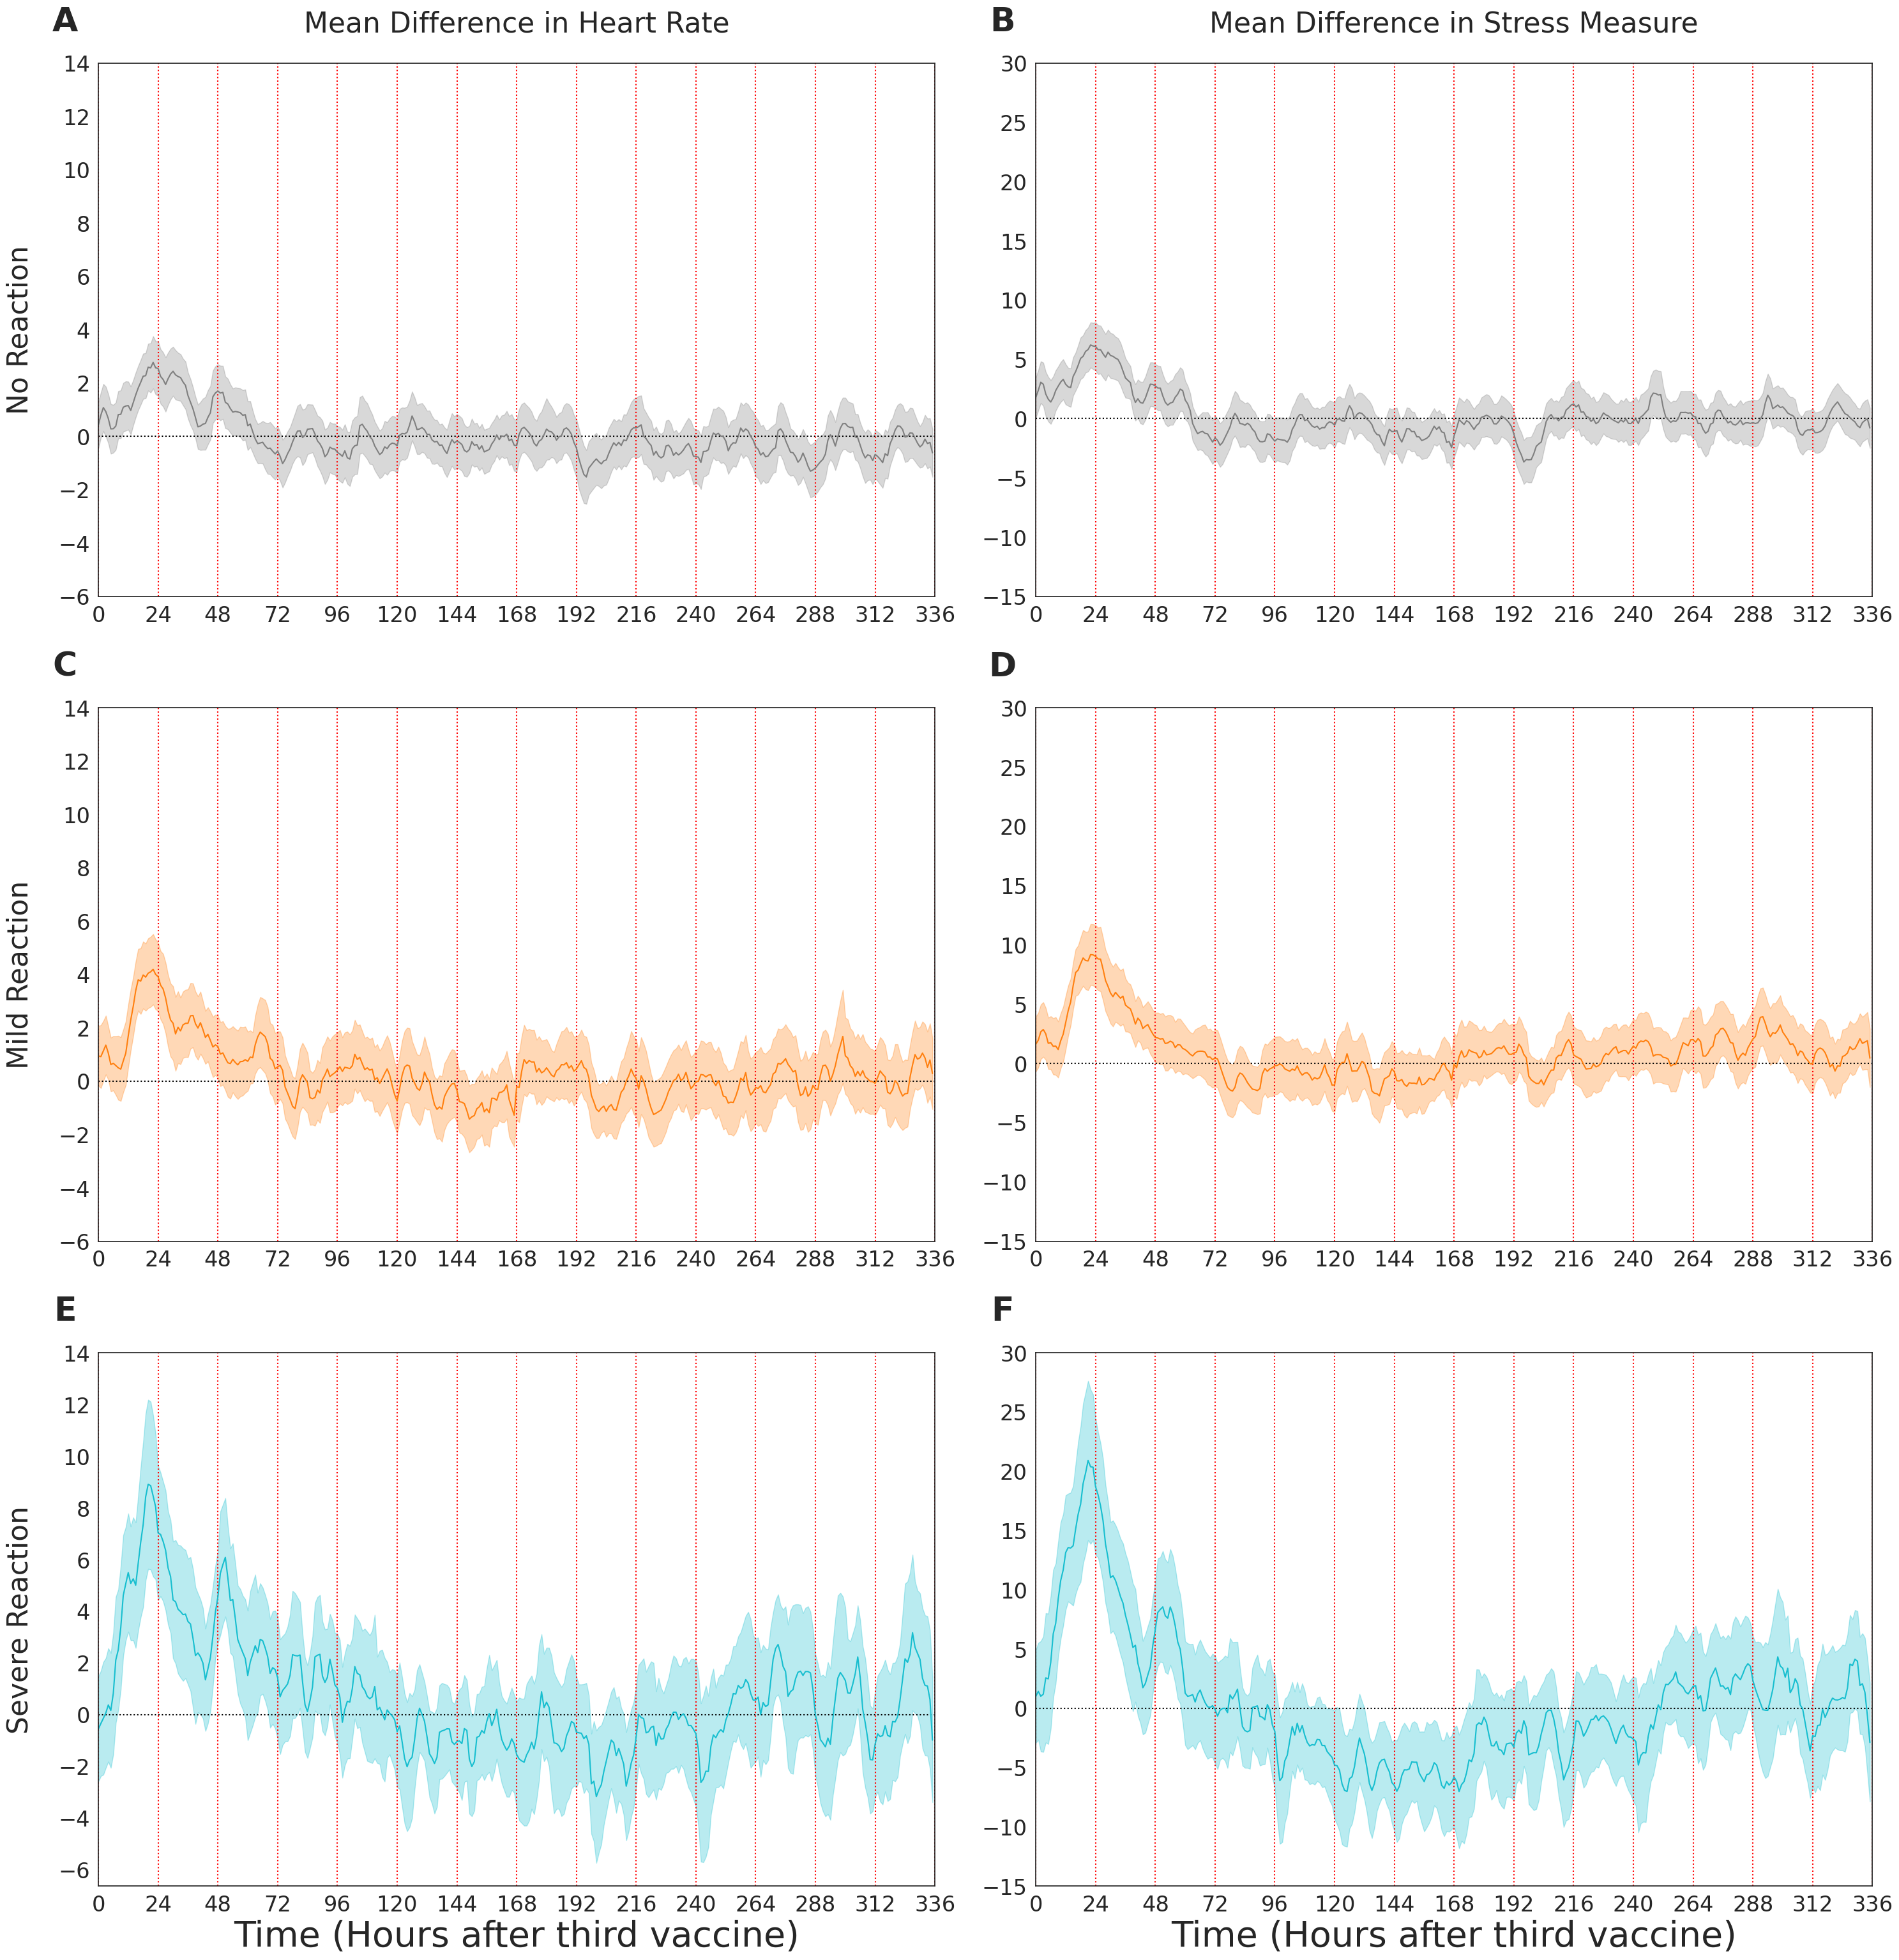

In [11]:
reaction_strength = {
    'No Reaction': v3_participant_nums[2],
    'Mild Reaction': v3_participant_nums[1],
    'Severe Reaction': v3_participant_nums[0],
}

indicators = [
    [{p: hr['third'][p] for p in hr['third'] if p in reaction_strength['No Reaction']},
     {p: hrv['third'][p] for p in hrv['third'] if p in reaction_strength['No Reaction']}],
    [{p: hr['third'][p] for p in hr['third'] if p in reaction_strength['Mild Reaction']},
     {p: hrv['third'][p] for p in hrv['third'] if p in reaction_strength['Mild Reaction']}],
    [{p: hr['third'][p] for p in hr['third'] if p in reaction_strength['Severe Reaction']},
     {p: hrv['third'][p] for p in hrv['third'] if p in reaction_strength['Severe Reaction']}]
]

fields = ['hourly_smoothed_diff', 'hourly_smoothed_diff', 'hourly_smoothed_diff']

col_labels = ['Mean Difference in Heart Rate', 'Mean Difference in Stress Measure']

xlabel = 'Time (Hours after third vaccine)'
ylabels = ['No Reaction', 'Mild Reaction', 'Severe Reaction']

xticks = range(0, 14*24+1, 24)
ytickss =  [np.arange(-6, 15, 2), np.arange(-15, 31, 5)]

pal = reaction_pal

figsize = (15*len(indicators[0]), 10*len(indicators))
fontsize = 25

plot_all_subfigures(indicators, fields, 0, 14, col_labels, xlabel, ylabels, xticks, ytickss, figsize, fontsize, pal, True)

In [12]:
indicator_participants = [
    [p for p in hr['third'] if p in reaction_strength['No Reaction']],
     [p for p in hrv['third'] if p in reaction_strength['No Reaction']],
    [p for p in hr['third'] if p in reaction_strength['Mild Reaction']],
     [p for p in hrv['third'] if p in reaction_strength['Mild Reaction']],
    [p for p in hr['third'] if p in reaction_strength['Severe Reaction']],
     [p for p in hrv['third'] if p in reaction_strength['Severe Reaction']]
]

with open('v3_participants_hr_garmin.pkl', 'wb') as handle:
    pkl.dump(indicator_participants, handle, protocol=pkl.HIGHEST_PROTOCOL)



# None, Mild, Severe reactions after 2nd vaccination

81
Sample size after removing all nulls = 75
Peak: 3.50 95% CI [1.50 - 5.50]; n=63)
79
Sample size after removing all nulls = 71
Peak: 6.77 95% CI [2.86 - 10.68]; n=60)
28
Sample size after removing all nulls = 26
Peak: 5.96 95% CI [2.91 - 9.01]; n=23)
28
Sample size after removing all nulls = 26
Peak: 15.09 95% CI [5.20 - 24.98]; n=22)
15
Sample size after removing all nulls = 15
Peak: 8.16 95% CI [0.10 - 16.23]; n=13)
15
Sample size after removing all nulls = 15
Peak: 16.27 95% CI [1.80 - 30.74]; n=13)


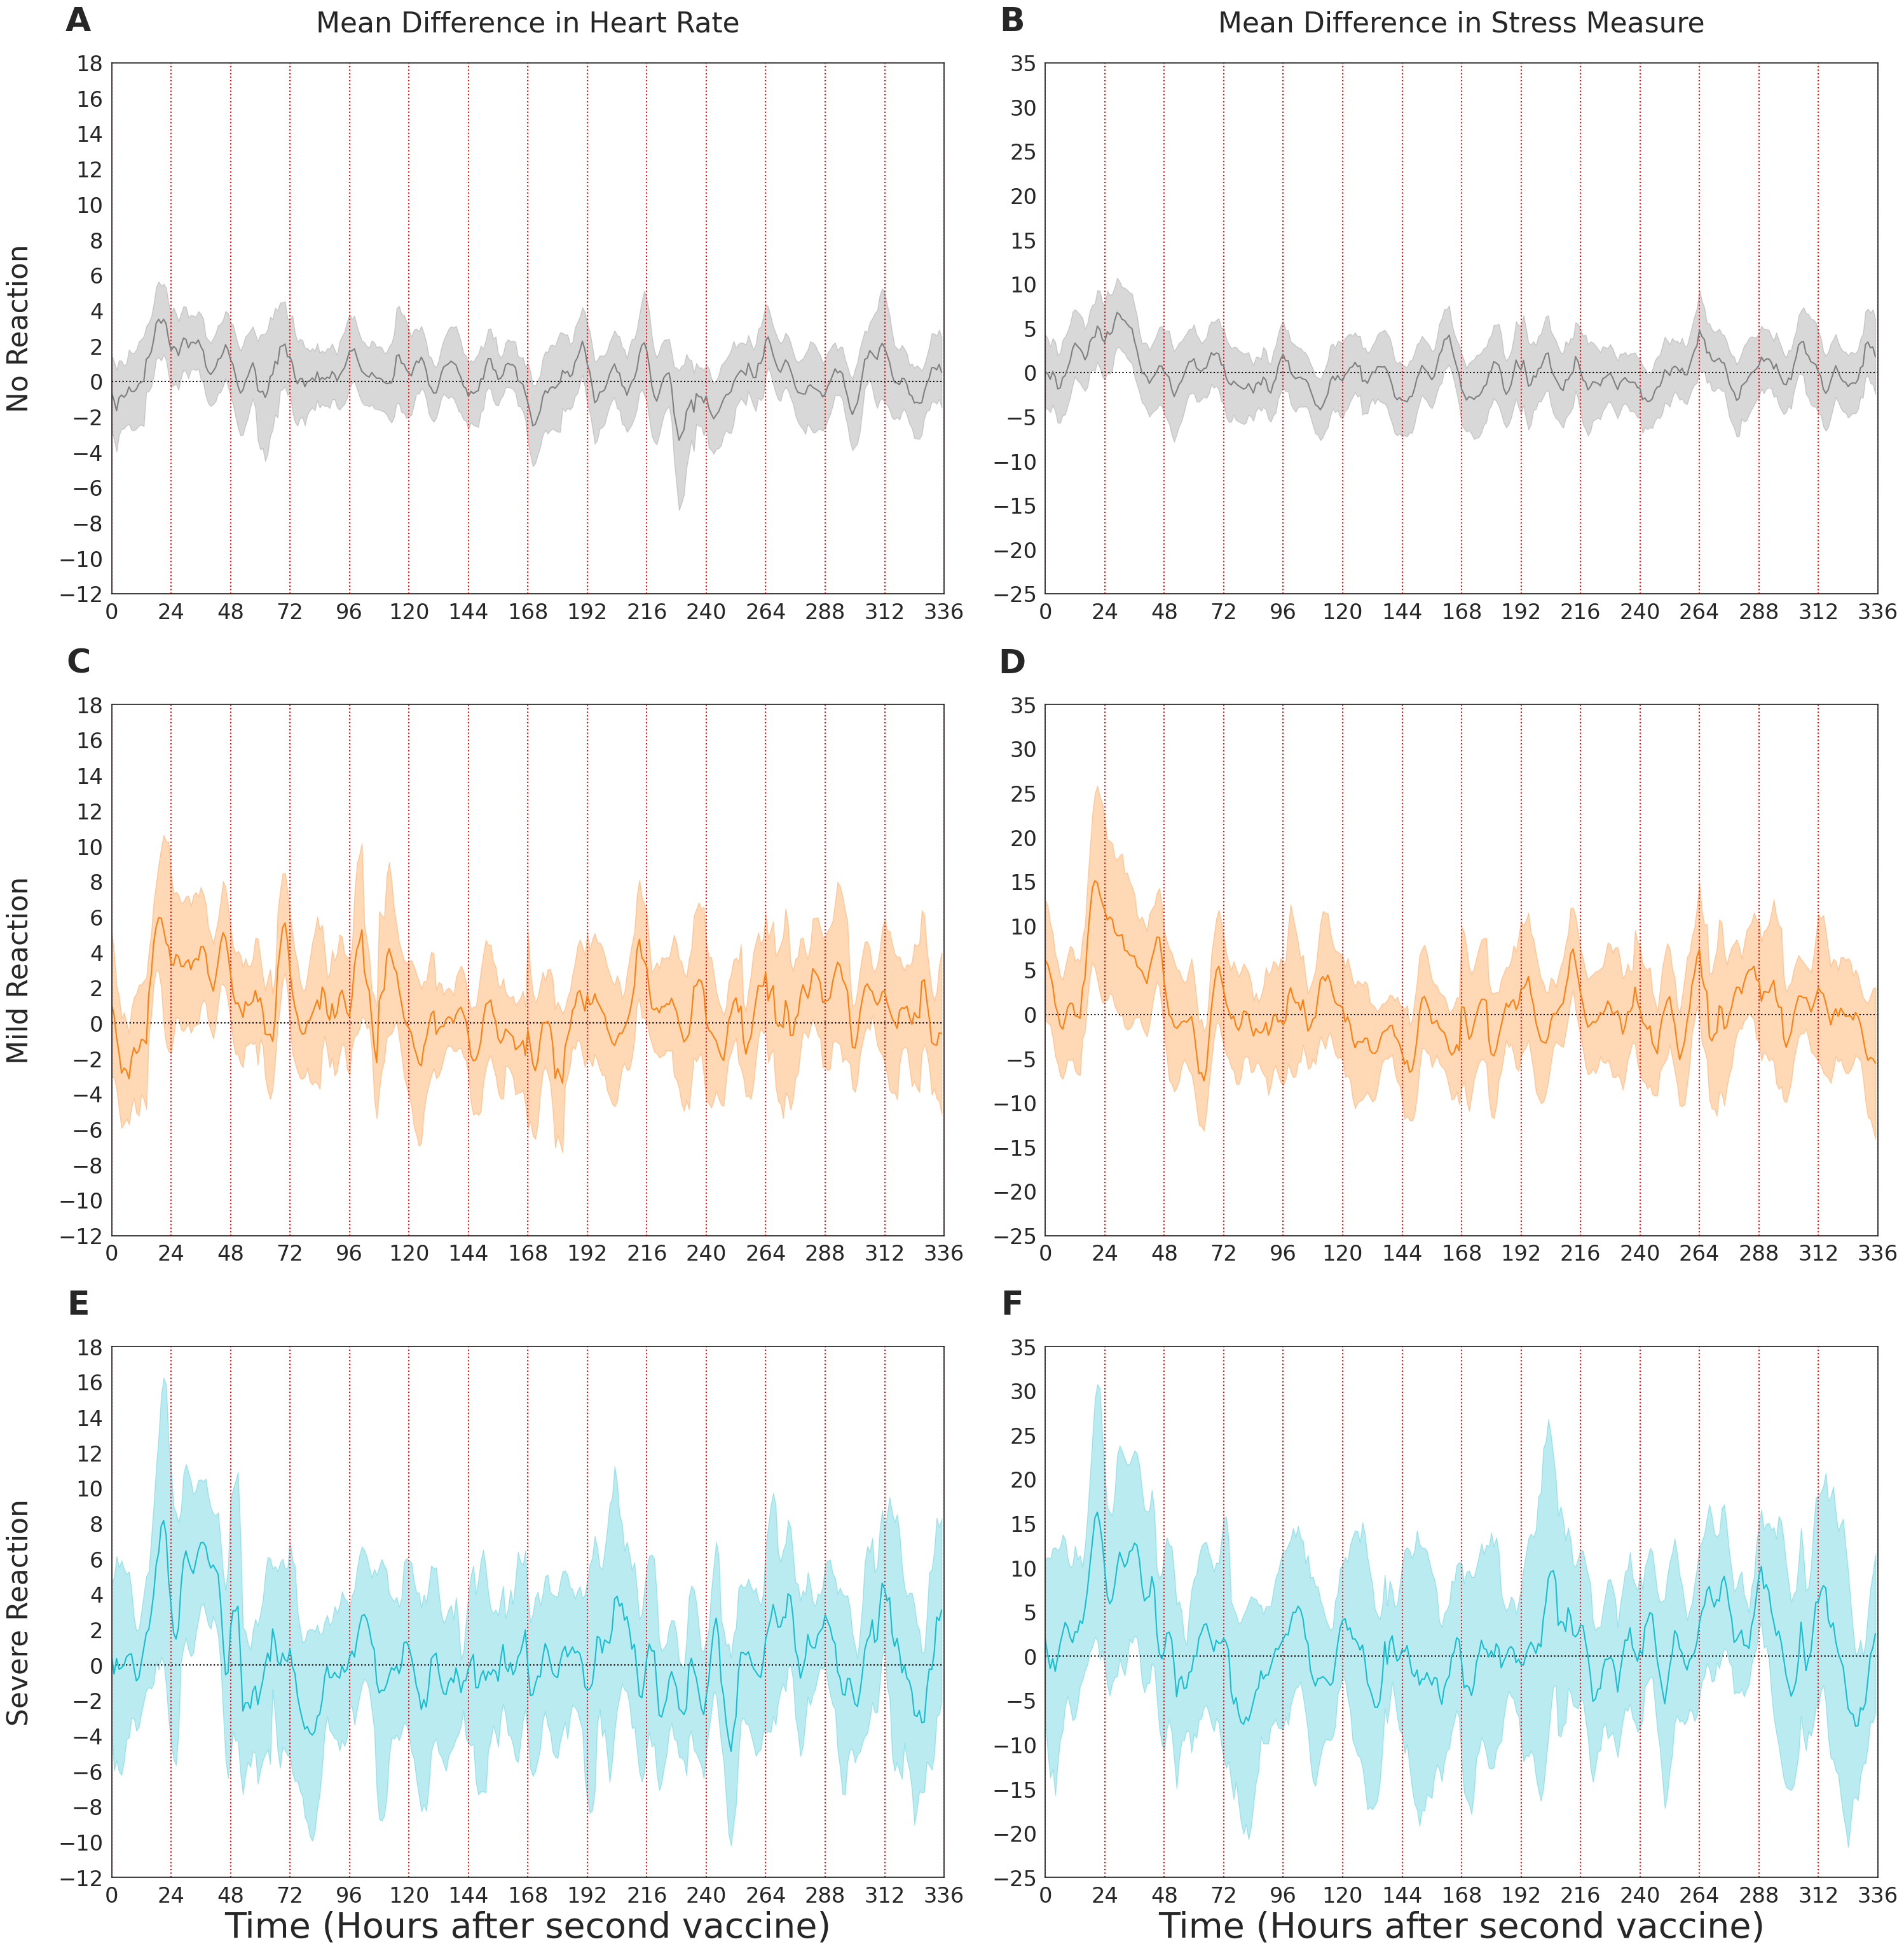

In [13]:
reaction_strength = {
    'No Reaction': v2_participant_nums[2],
    'Mild Reaction': v2_participant_nums[1],
    'Severe Reaction': v2_participant_nums[0],
}

indicators = [
    [{p: hr['second'][p] for p in hr['second'] if p in reaction_strength['No Reaction']},
     {p: hrv['second'][p] for p in hrv['second'] if p in reaction_strength['No Reaction']}],
    [{p: hr['second'][p] for p in hr['second'] if p in reaction_strength['Mild Reaction']},
     {p: hrv['second'][p] for p in hrv['second'] if p in reaction_strength['Mild Reaction']}],
    [{p: hr['second'][p] for p in hr['second'] if p in reaction_strength['Severe Reaction']},
     {p: hrv['second'][p] for p in hrv['second'] if p in reaction_strength['Severe Reaction']}]
]

fields = ['hourly_smoothed_diff', 'hourly_smoothed_diff', 'hourly_smoothed_diff']

col_labels = ['Mean Difference in Heart Rate', 'Mean Difference in Stress Measure']

xlabel = 'Time (Hours after second vaccine)'
ylabels = ['No Reaction', 'Mild Reaction', 'Severe Reaction']

xticks = range(0, 14*24+1, 24)
ytickss =  [np.arange(-12, 19, 2), np.arange(-25, 36, 5)]

pal = reaction_pal

figsize = (15*len(indicators[0]), 10*len(indicators))
fontsize = 25

plot_all_subfigures(indicators, fields, 0, 14, col_labels, xlabel, ylabels, xticks, ytickss, figsize, fontsize, pal, True)

# Type 3 analyses

In [14]:
def aggregate_data_type3(p_to_data, p, field, period_start, period_end):
    
    if p not in p_to_data:
        return None

    data = p_to_data[p]
    
    if field not in data:
        return None
    
    relevant_data = data[field][int(period_start*24):int(period_end*24)]
    
    cnt_not_none = sum([(1 if pd.notna(x) else 0) for x in relevant_data])
    if cnt_not_none<0:
        return None
    
    agg_avg = np.nanmean(relevant_data)

    
    return agg_avg

def plot_bar_groups(groups, pal, group_labels, series_labels, ylabel, figsize, fontsize):
    fig, ax = plt.subplots(figsize=figsize)

    X = np.arange(len(groups[0]))
    
    width = 0
    for i in range(len(groups)):
        group = groups[i]
        
        agg_mean = [g.mean() for g in group]
        agg_err = [scipy.stats.t.ppf(1-0.025, len(g) - 1)*g.std()/np.sqrt(len(g)) for g in group]
        print("Mean: %.3f, 95 CI: %.3f-%.3f" % (agg_mean[0], agg_mean[0] - agg_err[0], agg_mean[0] + agg_err[0]))
        print("Mean: %.3f, 95 CI: %.3f-%.3f" % (agg_mean[1], agg_mean[1] - agg_err[1], agg_mean[1] + agg_err[1]))

        plt.bar(X+width, agg_mean, 1/4, label=series_labels[i], color=pal[i])
        plt.errorbar(X+width,  agg_mean, yerr=agg_err, fmt='.k', ecolor='black')# capsize=8, 
        
        width += 1/4
        
    #plt.axhline(y=0, color='black', linestyle='dotted')
    
    ax.set_xticks(X+((len(groups)-1)/8))
    ax.set_xticklabels(group_labels, fontsize=fontsize)

    ax.tick_params(axis='y', labelsize=fontsize)
    
    plt.ylabel(ylabel, fontsize=fontsize)
    
    plt.legend(prop={'size': fontsize}, frameon=False, loc='upper left')
    
    plt.show()

In [15]:
df_anova = df_pinfo.copy()
for dose in ['first', 'second', 'third']:
    df_anova['hr' + '_' + dose] = df_anova['participant_num'].apply(
        lambda p: aggregate_data_type3(hr[dose], p, 'hourly_smoothed_diff', 0, 3))
    df_anova['hrv' + '_' + dose] = df_anova['participant_num'].apply(
        lambda p: aggregate_data_type3(hrv[dose], p, 'hourly_smoothed_diff', 0, 3))
    df_anova['spo2' + '_' + dose] = df_anova['participant_num'].apply(
        lambda p: aggregate_data_type3(spo2[dose], p, 'hourly_smoothed_diff', 0, 3))

<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)
<ipython-input-14-3651b3d81494>:17: RuntimeWarning: Mean of empty slice
  agg_avg = np.nanmean(relevant_data)


## By dose

Mean: 0.752, 95 CI: 0.613-0.892
Mean: 0.337, 95 CI: -0.036-0.710
Mean: 1.755, 95 CI: 1.467-2.043
Mean: 2.372, 95 CI: 2.061-2.682
Mean: 1.609, 95 CI: 1.418-1.800
Mean: 3.350, 95 CI: 2.959-3.741


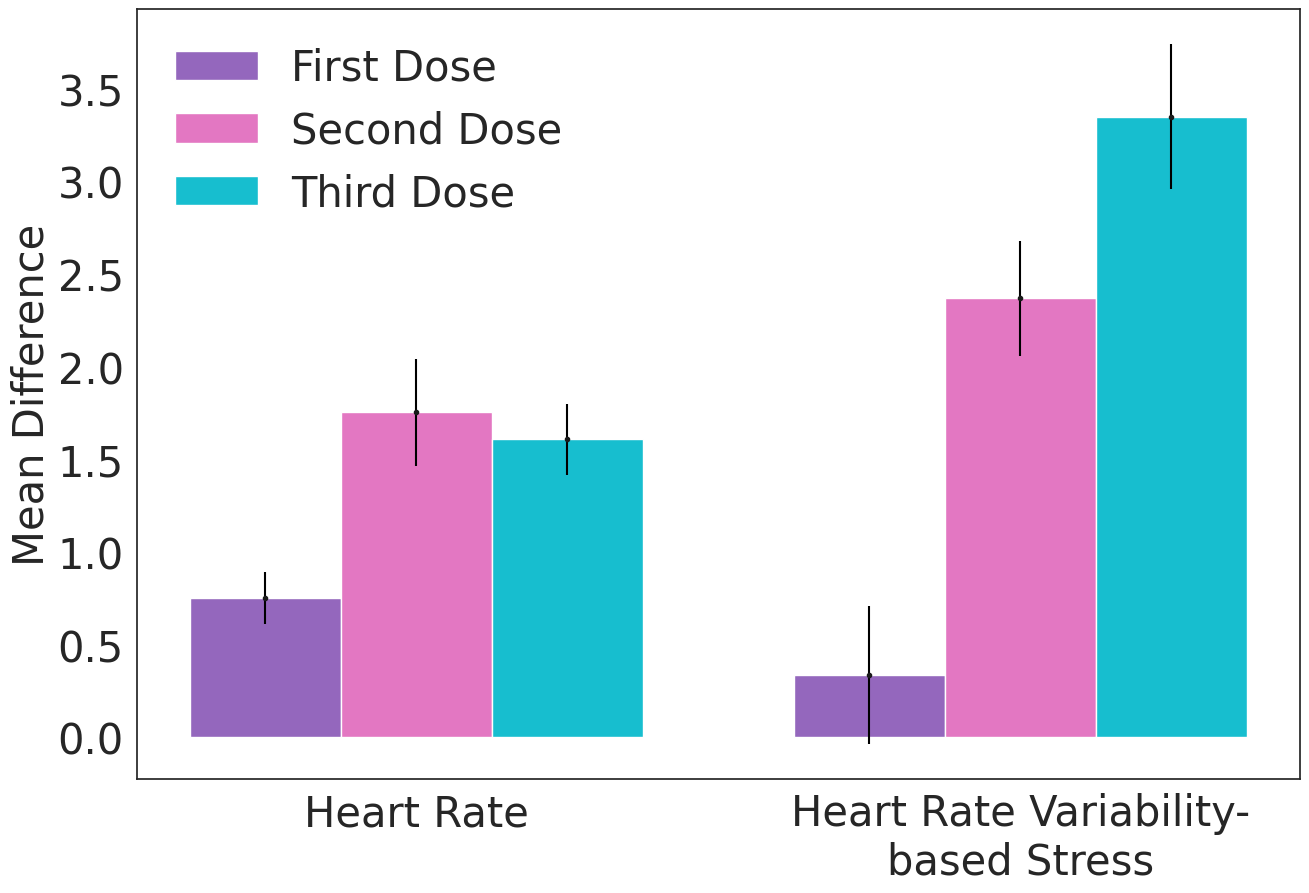

In [16]:
groups = [
    [df_anova['hr_first'], df_anova['hrv_first']],
    [df_anova['hr_second'], df_anova['hrv_second']],
    [df_anova['hr_third'], df_anova['hrv_third']],
]

pal = [sns.color_palette('tab10')[4], sns.color_palette('tab10')[6], sns.color_palette('tab10')[9]]

plot_bar_groups(groups, pal, ['Heart Rate', 'Heart Rate Variability-\nbased Stress'], ['First Dose', 'Second Dose', 'Third Dose'], 'Mean Difference', (15, 10), 30)

In [17]:
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[2][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[1][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][0].dropna(), groups[2][0].dropna(), equal_var=False))

print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[2][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[1][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][1].dropna(), groups[2][1].dropna(), equal_var=False))

Ttest_indResult(statistic=-2.374622059091321, pvalue=0.018525716287304116)
Ttest_indResult(statistic=-1.4498839051236838, pvalue=0.14851909549995568)
Ttest_indResult(statistic=0.2305521679662804, pvalue=0.8179418928477211)
Ttest_indResult(statistic=-3.199317488500981, pvalue=0.0016652004867181048)
Ttest_indResult(statistic=-1.8241941196323648, pvalue=0.06939679765675479)
Ttest_indResult(statistic=-1.278115392940197, pvalue=0.20263079290912916)


## By severity of reaction

Mean: 1.034, 95 CI: 0.643-1.426
Mean: 2.345, 95 CI: 1.569-3.121
Mean: 1.845, 95 CI: 1.406-2.284
Mean: 3.746, 95 CI: 2.833-4.659
Mean: 4.060, 95 CI: 3.055-5.065
Mean: 8.374, 95 CI: 6.267-10.480


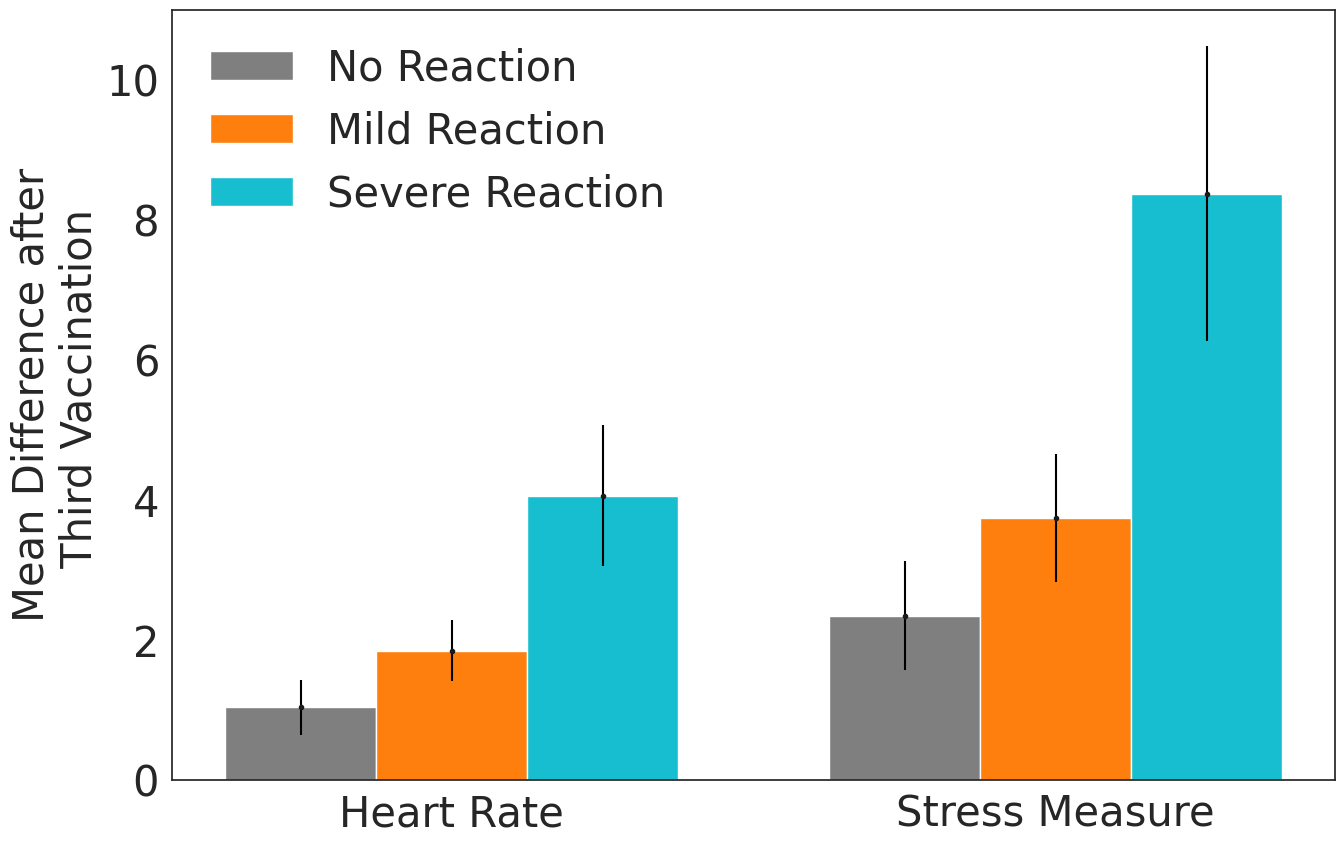

In [18]:
# Reset reaction strength to be after the 3rd vaccine for the following analyses

reaction_strength = {
    'No Reaction': v3_participant_nums[2],
    'Mild Reaction': v3_participant_nums[1],
    'Severe Reaction': v3_participant_nums[0]
}


reaction_dfs = [df_anova[df_anova['participant_num'].isin(reaction_strength[r])] for r in reactions]

groups = [
    [reaction_dfs[i]['hr_third'], reaction_dfs[i]['hrv_third']] for i in range(3)
]

pal = reaction_pal

plot_bar_groups(groups, pal, ['Heart Rate', 'Stress Measure'], reactions, 'Mean Difference after\n Third Vaccination', (15, 10), 30)

In [19]:
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[2][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[1][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][0].dropna(), groups[2][0].dropna(), equal_var=False))

print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[2][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[1][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][1].dropna(), groups[2][1].dropna(), equal_var=False))

Ttest_indResult(statistic=-4.459785165895469, pvalue=2.159226955650258e-05)
Ttest_indResult(statistic=-2.209289325809215, pvalue=0.027522688649915413)
Ttest_indResult(statistic=-3.2070464732561255, pvalue=0.0017721608779166322)
Ttest_indResult(statistic=-4.238982789212589, pvalue=5.170934020708569e-05)
Ttest_indResult(statistic=-1.8687485101010748, pvalue=0.06214679860433677)
Ttest_indResult(statistic=-3.1833277568964373, pvalue=0.0019211504010526695)


Mean: 0.641, 95 CI: -0.228-1.509
Mean: 1.019, 95 CI: -0.622-2.660
Mean: 1.983, 95 CI: 0.816-3.149
Mean: 3.942, 95 CI: 0.907-6.976
Mean: 3.286, 95 CI: 0.444-6.128
Mean: 6.286, 95 CI: 0.791-11.781


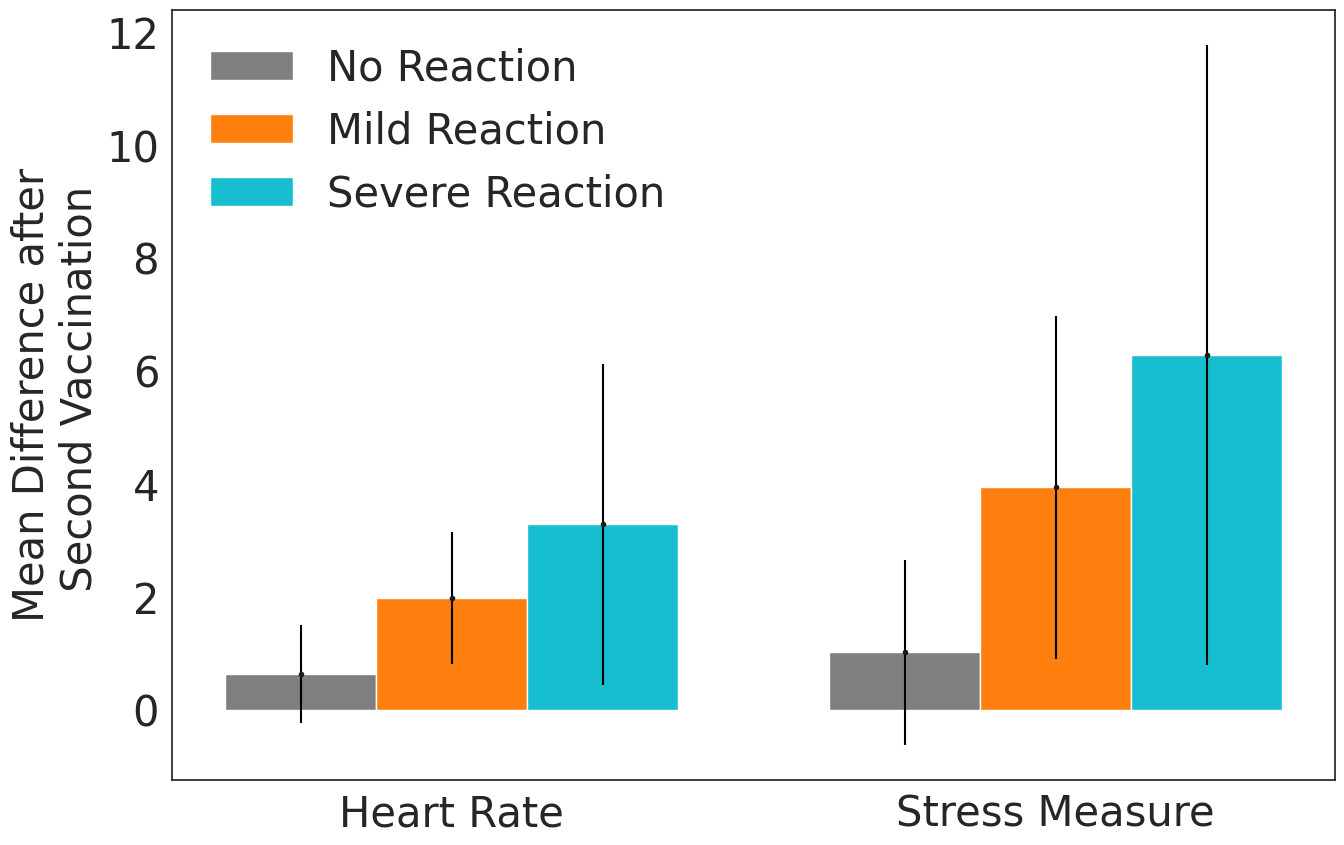

In [20]:
# Reset reaction strength to be after the 3rd vaccine for the following analyses

reaction_strength = {
    'No Reaction': v2_participant_nums[2],
    'Mild Reaction': v2_participant_nums[1],
    'Severe Reaction': v2_participant_nums[0],
}

reaction_dfs = [df_anova[df_anova['participant_num'].isin(reaction_strength[r])] for r in reactions]

groups = [
    [reaction_dfs[i]['hr_second'], reaction_dfs[i]['hrv_second']] for i in range(3)
]

pal = reaction_pal

plot_bar_groups(groups, pal, ['Heart Rate', 'Stress Measure'], reactions, 'Mean Difference after\n Second Vaccination', (15, 10), 30)

In [21]:
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[2][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[1][0].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][0].dropna(), groups[2][0].dropna(), equal_var=False))

print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[2][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[1][1].dropna(), equal_var=False))
print(scipy.stats.ttest_ind(groups[1][1].dropna(), groups[2][1].dropna(), equal_var=False))

Ttest_indResult(statistic=-1.8762976456043279, pvalue=0.077021672451286)
Ttest_indResult(statistic=-1.740258012603918, pvalue=0.08702740293292034)
Ttest_indResult(statistic=-0.895952211195198, pvalue=0.38099177445961807)
Ttest_indResult(statistic=-1.9304837901063332, pvalue=0.06951177006350345)
Ttest_indResult(statistic=-1.6020369324337547, pvalue=0.11628746749365931)
Ttest_indResult(statistic=-0.7809668521840335, pvalue=0.44230831567539874)


Mean: 1.160, 95 CI: 0.788-1.533
Mean: 2.440, 95 CI: 1.603-3.278
Mean: 1.481, 95 CI: 1.156-1.806
Mean: 3.684, 95 CI: 3.021-4.346
Mean: 2.032, 95 CI: 1.737-2.328
Mean: 3.437, 95 CI: 2.844-4.029


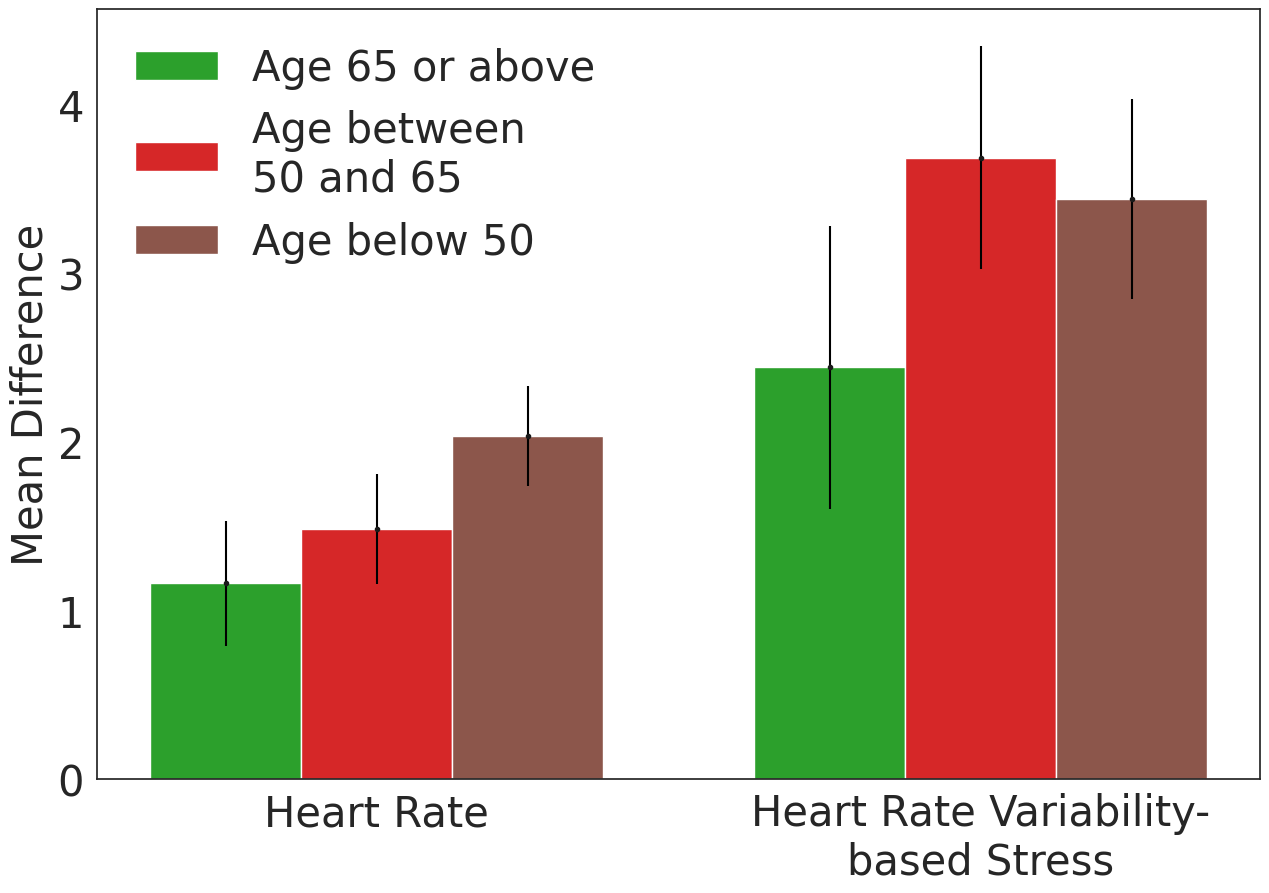

In [22]:
groups = [
    [df_anova[df_anova['age_group']=='>=65']['hr_third'], df_anova[df_anova['age_group']=='>=65']['hrv_third']],
    [df_anova[df_anova['age_group']=='>=50']['hr_third'], df_anova[df_anova['age_group']=='>=50']['hrv_third']],
    [df_anova[df_anova['age_group']=='<50']['hr_third'], df_anova[df_anova['age_group']=='<50']['hrv_third']],
]

pal = [sns.color_palette('tab10')[2], sns.color_palette('tab10')[3], sns.color_palette('tab10')[5]]

plot_bar_groups(groups, pal, ['Heart Rate', 'Heart Rate Variability-\nbased Stress'], ['Age 65 or above', 'Age between\n50 and 65', 'Age below 50'], 'Mean Difference', (15, 10), 30)

In [23]:
hrv_labels = ['Heart Rate', 'Heart Rate Variability-\nbased Stress']

In [24]:
col_names = [
    'age_group',
    'gender',
    'comorbidity'
]

labels = [
    ['>=65', '>=50', '<50'],
    ['Male', 'Female'],
    ['Yes', 'No']
]

palettes = [
    [sns.color_palette('tab10')[2], sns.color_palette('tab10')[3], sns.color_palette('tab10')[5]],
    [sns.color_palette('tab10')[0], sns.color_palette('tab10')[1]],
    ['teal','plum']
]

legend_labels = [
    ['Age 65 or above', 'Age between\n50 and 65', 'Age below 50'],
    ['Male', 'Female'],
    ['Underlying Medical\nCondition', 'No Underlying\nMedical Condition']
]

In [25]:
group_name_to_df = {
    "Severe Reaction": reaction_dfs[0],
    "Mild Reaction": reaction_dfs[1],
    "No Reaction": reaction_dfs[2],
    "All Participants": df_anova
}

In [26]:
group_name_to_groups_lists_to_plot = dict()

for group_name, group_df in group_name_to_df.items():
    print(group_name)
    groups_list = list()
    for i in range(len(col_names)):
        col_name = col_names[i]
        label_arr = labels[i]
        #pal = palettes[i]
        #legend_arr = legend_labels[i]
        print(col_name)

        groups = [
            [group_df[group_df[col_name]==lab]['hr_third'],
             group_df[group_df[col_name]==lab]['hrv_third']] for lab in label_arr]

        groups_list.append(groups)

        #plot_bar_groups(groups, pal, hrv_labels, legend_arr, 'Mean Difference', (15, 10), 30)

        if len(label_arr) == 3:
            print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[2][0].dropna(), equal_var=False))
            print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[1][0].dropna(), equal_var=False))
            print(scipy.stats.ttest_ind(groups[1][0].dropna(), groups[2][0].dropna(), equal_var=False))

            print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[2][1].dropna(), equal_var=False))
            print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[1][1].dropna(), equal_var=False))
            print(scipy.stats.ttest_ind(groups[1][1].dropna(), groups[2][1].dropna(), equal_var=False))
        else:
            print(scipy.stats.ttest_ind(groups[0][0].dropna(), groups[1][0].dropna(), equal_var=False))
            print(scipy.stats.ttest_ind(groups[0][1].dropna(), groups[1][1].dropna(), equal_var=False))
    group_name_to_groups_lists_to_plot[group_name] = groups_list
    print("\n")

Severe Reaction
age_group
Ttest_indResult(statistic=0.39172940972007786, pvalue=0.71232154455394)
Ttest_indResult(statistic=-0.3472005063212668, pvalue=0.7304665214894628)
Ttest_indResult(statistic=0.5251014526570568, pvalue=0.6245873352028669)
Ttest_indResult(statistic=1.3473226937480627, pvalue=0.22861140532872465)
Ttest_indResult(statistic=1.28728958030082, pvalue=0.20638879166225185)
Ttest_indResult(statistic=0.5006827828382544, pvalue=0.6394743674901711)
gender
Ttest_indResult(statistic=0.43555563552151466, pvalue=0.6648720366572201)
Ttest_indResult(statistic=0.06168379805561642, pvalue=0.9510648556618844)
comorbidity
Ttest_indResult(statistic=-0.761398350154747, pvalue=0.4501905780488943)
Ttest_indResult(statistic=-0.04793802923834455, pvalue=0.9621006671645456)


Mild Reaction
age_group
Ttest_indResult(statistic=-0.42525891553943634, pvalue=0.6925348204403169)
Ttest_indResult(statistic=-2.2859631393887523, pvalue=0.10513188055443745)
Ttest_indResult(statistic=1.7164985134166828,

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3757: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:256: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
